# IBKR Trade EDA

Fetch full trade execution history via the **IBKR Flex Web Service** and perform comprehensive exploratory data analysis.

**Prerequisites:**
1. `.env` file configured with:
   - `IBKR_FLEX_TOKEN` — Flex Web Service access token
   - `IBKR_FLEX_QUERY_ID` — Activity Flex Query ID
   - `IBKR_ACCOUNT_ID` — your account ID (or set `ACCOUNT_ID` in the Config cell below)
2. `ibflex` installed: `pip install ibflex`

> Flex queries return **years of execution history** with no live IB Gateway connection required.

## 0 — Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

from ibkr_eda import IBKR

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 4)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.4f}".format)

In [2]:
# ── Configuration ──────────────────────────────────────────────────────────────
ACCOUNT_ID = "U14593335"          # Override here if needed
DATA_DIR   = Path("../data")
CSV_PATH   = DATA_DIR / f"trades_{ACCOUNT_ID}.csv"
DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"Account  : {ACCOUNT_ID}")
print(f"CSV path : {CSV_PATH.resolve()}")

Account  : U14593335
CSV path : C:\Users\Ferhat\Documents\GitHub\ibkr-eda\data\trades_U14593335.csv


## 1 — Fetch & Persist Trades

In [3]:
from ibkr_eda.config import IBKRConfig
from ibkr_eda.trades.flex import FlexTrades

config = IBKRConfig.from_env()
flex = FlexTrades(config)

print(f"Token    : {'set' if config.flex_token else 'MISSING — add IBKR_FLEX_TOKEN to .env'}")
print(f"Query ID : {config.flex_query_id or 'MISSING — add IBKR_FLEX_QUERY_ID to .env'}")

Token    : set
Query ID : 1422169


In [4]:
print("Fetching execution history via Flex Web Service...")
fresh = flex.get(account_id=ACCOUNT_ID)
print(f"Fetched {len(fresh)} execution(s) via Flex Query")

Fetching execution history via Flex Web Service...
Fetched 826 execution(s) via Flex Query


In [5]:
# Load existing history and merge (deduplicate on execution_id)
if CSV_PATH.exists():
    existing = pd.read_csv(CSV_PATH, parse_dates=["trade_time"])
    print(f"Loaded {len(existing)} existing row(s) from {CSV_PATH.name}")
else:
    existing = pd.DataFrame()
    print("No existing CSV — starting fresh.")

if not fresh.empty:
    fresh["trade_time"] = pd.to_datetime(fresh["trade_time"], utc=True)
    combined = pd.concat([existing, fresh], ignore_index=True)
    combined = combined.drop_duplicates(subset="execution_id", keep="last")
    combined = combined.sort_values("trade_time").reset_index(drop=True)
else:
    combined = existing
    print("No new executions returned by TWS (history may be older than 7 days).")

print(f"Total rows after merge: {len(combined)}")

No existing CSV — starting fresh.
Total rows after merge: 826


In [6]:
if not combined.empty:
    combined.to_csv(CSV_PATH, index=False)
    print(f"Saved {len(combined)} rows → {CSV_PATH}")

Saved 826 rows → ..\data\trades_U14593335.csv


In [ ]:
# Flex queries are stateless HTTP calls — no connection to close.

## 2 — Data Quality & Preview

In [7]:
if combined.empty:
    raise SystemExit("No trade data available. Run after accumulating at least one fetch.")

df = combined.copy()
df["trade_time"] = pd.to_datetime(df["trade_time"], utc=True)
df["notional"]   = df["quantity"] * df["price"]
df["date"]       = df["trade_time"].dt.normalize()
df["hour"]       = df["trade_time"].dt.hour
df["weekday"]    = df["trade_time"].dt.day_name()
df["month"]      = df["trade_time"].dt.to_period("M")

C:\Users\Ferhat\AppData\Local\Temp\ipykernel_8448\3679440674.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"]      = df["trade_time"].dt.to_period("M")


In [8]:
print(f"Shape  : {df.shape}")
print(f"Date range: {df['trade_time'].min().date()} → {df['trade_time'].max().date()}")
print("\nNull counts:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape  : (826, 19)
Date range: 2025-03-03 → 2026-03-02

Null counts:
order_ref    826
dtype: int64


In [9]:
df.head(10)

,execution_id,contract_id,symbol,sec_type,currency,side,quantity,price,order_ref,account_id,exchange,commission,realized_pnl,trade_time,notional,date,hour,weekday,month
0,268370321,12345775,GBP.HKD,CASH,HKD,SELL,"-2,614.7500",9.7912,None,U14593335,IDEALFX,0.0000,0.0000,2025-03-03 02:27:53+00:00,"-25,601.5663",2025-03-03 00:00:00+00:00,2,Monday,2025-03
1,268370312,259933925,981,STK,HKD,BUY,500.0000,51.1500,None,U14593335,SEHK,20.4600,0.0000,2025-03-03 02:27:53+00:00,"25,575.0000",2025-03-03 00:00:00+00:00,2,Monday,2025-03
2,268370313,12345775,GBP.HKD,CASH,HKD,SELL,-2.0900,9.7916,None,U14593335,IDEALFX,0.0000,0.0000,2025-03-03 02:27:53+00:00,-20.4645,2025-03-03 00:00:00+00:00,2,Monday,2025-03
3,268370314,12345775,GBP.HKD,CASH,HKD,SELL,-0.0200,9.7912,None,U14593335,IDEALFX,0.0000,0.0000,2025-03-03 02:27:54+00:00,-0.1958,2025-03-03 00:00:00+00:00,2,Monday,2025-03
4,268484289,12345775,GBP.HKD,CASH,HKD,BUY,0.0005,9.8810,None,U14593335,IDEALFX,0.0000,0.0000,2025-03-03 17:00:00+00:00,0.0045,2025-03-03 00:00:00+00:00,17,Monday,2025-03
5,268484495,12087797,GBP.USD,CASH,USD,BUY,2.7627,1.2705,None,U14593335,IDEALFX,0.0000,0.0000,2025-03-03 17:00:00+00:00,3.5100,2025-03-03 00:00:00+00:00,17,Monday,2025-03
6,268485199,12345775,GBP.HKD,CASH,HKD,BUY,0.0034,9.8809,None,U14593335,IDEALFX,0.0000,0.0000,2025-03-03 17:00:00+00:00,0.0333,2025-03-03 00:00:00+00:00,17,Monday,2025-03
7,269103226,86656185,SGLN,STK,GBP,BUY,70.0000,43.5900,None,U14593335,LSEETF,3.0000,0.0000,2025-03-10 07:30:36+00:00,"3,051.3000",2025-03-10 00:00:00+00:00,7,Monday,2025-03
8,269155062,9160,LLY,STK,USD,SELL,-2.0000,843.2100,None,U14593335,IBKRATS,1.0473,7.3677,2025-03-10 12:12:46+00:00,"-1,686.4200",2025-03-10 00:00:00+00:00,12,Monday,2025-03
9,269155803,4815747,NVDA,STK,USD,BUY,10.0000,107.6850,None,U14593335,ARCA,1.0004,0.0000,2025-03-10 12:16:34+00:00,"1,076.8500",2025-03-10 00:00:00+00:00,12,Monday,2025-03


## 3 — Summary Statistics

In [10]:
total_trades  = len(df)
buys          = (df["side"].str.upper().isin(["BUY", "BOT"])).sum()
sells         = (df["side"].str.upper().isin(["SELL", "SLD"])).sum()
total_qty     = df["quantity"].sum()
total_notional = df["notional"].sum()
total_pnl     = df["realized_pnl"].dropna().sum()
total_comm    = df["commission"].dropna().sum()
winners       = (df["realized_pnl"] > 0).sum()
losers        = (df["realized_pnl"] < 0).sum()
win_rate      = winners / (winners + losers) * 100 if (winners + losers) > 0 else float("nan")
avg_pnl       = df["realized_pnl"].dropna().mean()

print("══════════════════════════════")
print(f"  Total executions  : {total_trades:,}")
print(f"  Buys              : {buys:,}")
print(f"  Sells             : {sells:,}")
print(f"  Total shares      : {total_qty:,.0f}")
print(f"  Total notional    : ${total_notional:,.2f}")
print(f"  Realized P&L      : ${total_pnl:,.2f}")
print(f"  Commission paid   : ${total_comm:,.2f}")
print(f"  Win rate          : {win_rate:.1f}%")
print(f"  Avg P&L/trade     : ${avg_pnl:,.2f}")
print("══════════════════════════════")

══════════════════════════════
  Total executions  : 826
  Buys              : 345
  Sells             : 481
  Total shares      : 222
  Total notional    : $-1,102.75
  Realized P&L      : $17,976.18
  Commission paid   : $600.31
  Win rate          : 60.2%
  Avg P&L/trade     : $21.76
══════════════════════════════


## 4 — P&L Analysis

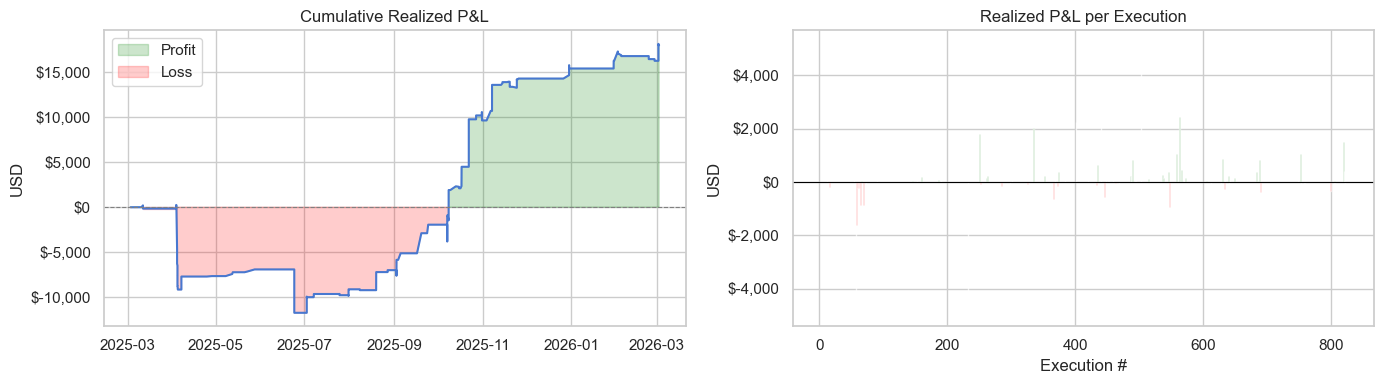

In [11]:
pnl_df = df.dropna(subset=["realized_pnl"]).copy()
pnl_df = pnl_df.sort_values("trade_time")
pnl_df["cum_pnl"] = pnl_df["realized_pnl"].cumsum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Cumulative P&L
axes[0].plot(pnl_df["trade_time"], pnl_df["cum_pnl"], linewidth=1.5)
axes[0].axhline(0, color="grey", linewidth=0.8, linestyle="--")
axes[0].fill_between(
    pnl_df["trade_time"],
    pnl_df["cum_pnl"],
    0,
    where=pnl_df["cum_pnl"] >= 0,
    alpha=0.2,
    color="green",
    label="Profit",
)
axes[0].fill_between(
    pnl_df["trade_time"],
    pnl_df["cum_pnl"],
    0,
    where=pnl_df["cum_pnl"] < 0,
    alpha=0.2,
    color="red",
    label="Loss",
)
axes[0].set_title("Cumulative Realized P&L")
axes[0].set_ylabel("USD")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].legend()

# P&L distribution
colors = ["green" if v >= 0 else "red" for v in pnl_df["realized_pnl"]]
axes[1].bar(range(len(pnl_df)), pnl_df["realized_pnl"], color=colors, alpha=0.7, width=0.8)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Realized P&L per Execution")
axes[1].set_ylabel("USD")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[1].set_xlabel("Execution #")

plt.tight_layout()
plt.show()

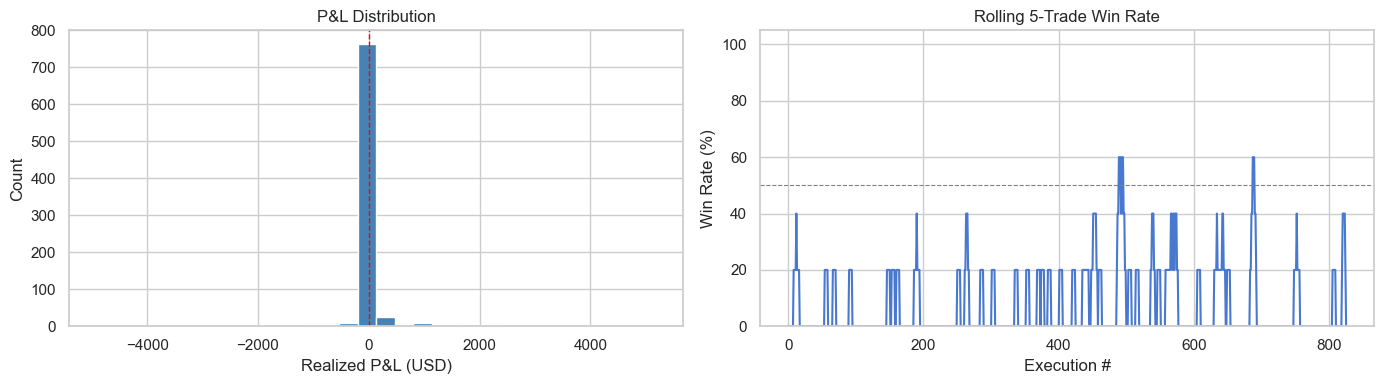

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(pnl_df["realized_pnl"], bins=30, edgecolor="white", color="steelblue")
axes[0].axvline(0, color="red", linewidth=1, linestyle="--")
axes[0].set_title("P&L Distribution")
axes[0].set_xlabel("Realized P&L (USD)")
axes[0].set_ylabel("Count")

# Rolling win rate (window=5)
pnl_df["winner"] = (pnl_df["realized_pnl"] > 0).astype(int)
rolling_wr = pnl_df["winner"].rolling(5, min_periods=1).mean() * 100
axes[1].plot(range(len(rolling_wr)), rolling_wr, linewidth=1.5)
axes[1].axhline(50, color="grey", linestyle="--", linewidth=0.8)
axes[1].set_title("Rolling 5-Trade Win Rate")
axes[1].set_xlabel("Execution #")
axes[1].set_ylabel("Win Rate (%)")
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.show()

In [13]:
cols = ["trade_time", "symbol", "side", "quantity", "price", "realized_pnl"]
print("Top 10 Winning Trades")
display(pnl_df.nlargest(10, "realized_pnl")[cols].reset_index(drop=True))

print("\nTop 10 Losing Trades")
display(pnl_df.nsmallest(10, "realized_pnl")[cols].reset_index(drop=True))

Top 10 Winning Trades


,trade_time,symbol,side,quantity,price,realized_pnl
0,2025-10-22 10:19:39+00:00,OKLO,SELL,-50.0000,125.7150,"5,169.1389"
1,2025-11-07 11:16:50+00:00,NVDA,SELL,-35.0000,179.4500,"2,440.3771"
2,2025-10-07 14:07:50+00:00,OKLO,SELL,-20.0000,134.3400,"2,258.5955"
3,2025-09-19 15:14:14+00:00,OKLO,SELL,-20.0000,132.8000,"2,227.7955"
4,2025-08-19 13:44:40+00:00,NVDA,SELL,-20.0000,176.8300,"2,005.8362"
5,2025-07-02 15:57:08+00:00,NVDA,SELL,-20.0000,157.4050,"1,797.0961"
6,2025-09-02 12:50:40+00:00,AMD,SELL,-30.0000,159.8300,"1,539.3932"
7,2025-10-08 12:53:49+00:00,NBIS,SELL,-20.0000,121.8300,"1,506.5291"
8,2026-03-02 06:12:24+00:00,NVDA,SELL,-19.0000,174.5100,"1,478.9006"
9,2025-04-07 04:19:33+00:00,RHMd,SELL,-6.0000,"1,167.0000","1,442.6990"



Top 10 Losing Trades


,trade_time,symbol,side,quantity,price,realized_pnl
0,2025-04-04 04:53:24+00:00,NOVOBc,SELL,-11.0000,450.1000,"-4,900.5000"
1,2025-06-24 01:22:41+00:00,981,SELL,-500.0000,41.7000,"-4,811.7831"
2,2025-10-07 13:53:42+00:00,MRNA,SELL,-40.0000,27.1600,"-1,762.3582"
3,2025-04-04 04:53:24+00:00,NOVOBc,SELL,-4.0000,450.1000,"-1,606.0000"
4,2025-10-31 13:35:22+00:00,CRCL,SELL,-18.0000,125.7900,-932.1839
5,2025-04-04 11:16:17+00:00,LAR,SELL,-524.0000,1.9150,-879.3546
6,2025-04-04 11:17:48+00:00,LAC,SELL,-505.0000,2.5500,-874.6623
7,2025-09-02 12:49:12+00:00,CRCL,SELL,-17.0000,121.2400,-622.1738
8,2025-11-19 15:55:25+00:00,ORCL,SELL,-10.0000,226.2150,-567.7021
9,2025-10-08 12:52:38+00:00,VKTX,SELL,-80.0000,33.7800,-550.8462


## 5 — Symbol & Asset Breakdown

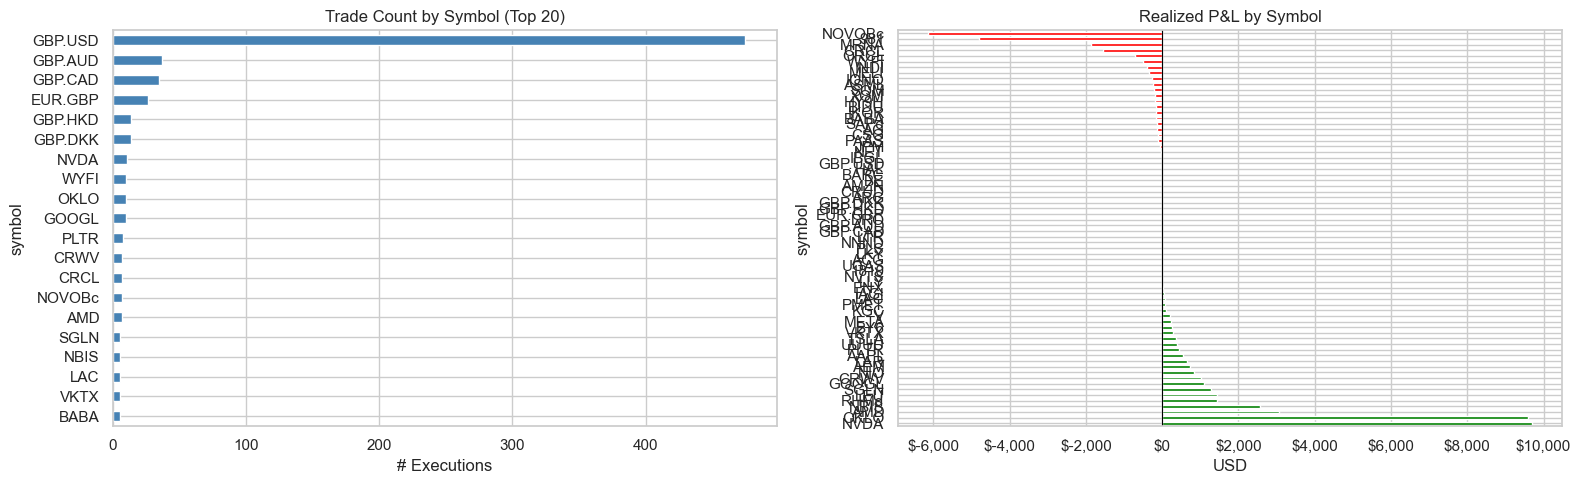

In [14]:
sym_count = df.groupby("symbol").size().sort_values(ascending=False).head(20)
sym_pnl   = pnl_df.groupby("symbol")["realized_pnl"].sum().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Trade count by symbol
sym_count.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Trade Count by Symbol (Top 20)")
axes[0].set_xlabel("# Executions")
axes[0].invert_yaxis()

# P&L by symbol
colors = ["green" if v >= 0 else "red" for v in sym_pnl.values]
sym_pnl.plot(kind="barh", ax=axes[1], color=colors)
axes[1].set_title("Realized P&L by Symbol")
axes[1].set_xlabel("USD")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

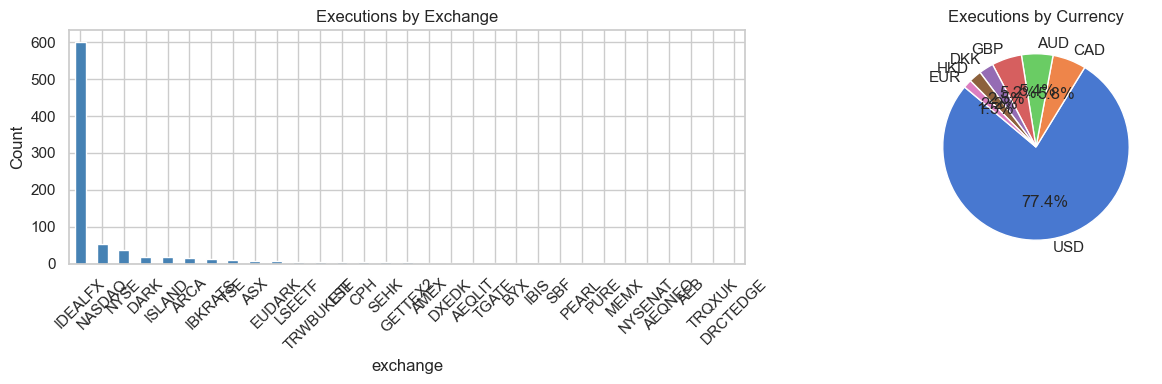

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Exchange breakdown
exch = df["exchange"].value_counts()
exch.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Executions by Exchange")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# Currency breakdown
if "currency" in df.columns:
    curr = df["currency"].value_counts()
    axes[1].pie(curr.values, labels=curr.index, autopct="%1.1f%%", startangle=140)
    axes[1].set_title("Executions by Currency")
else:
    axes[1].text(0.5, 0.5, "currency column not available", ha="center", va="center")

plt.tight_layout()
plt.show()

## 6 — Time-Based Patterns & Seasonality

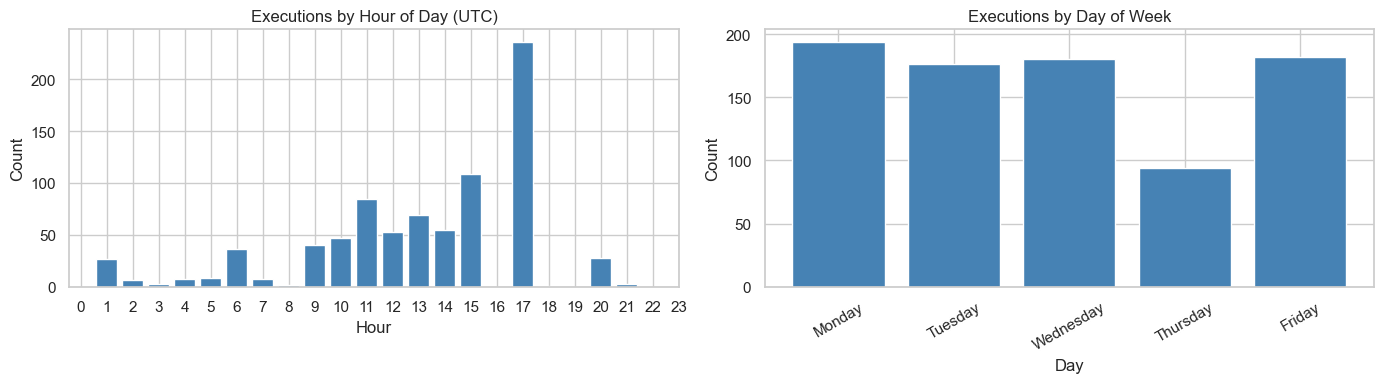

In [16]:
WEEKDAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Hour of day
hour_counts = df["hour"].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values, color="steelblue")
axes[0].set_title("Executions by Hour of Day (UTC)")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Count")
axes[0].set_xticks(range(0, 24))

# Day of week
dow = df["weekday"].value_counts().reindex(WEEKDAY_ORDER).dropna()
axes[1].bar(dow.index, dow.values, color="steelblue")
axes[1].set_title("Executions by Day of Week")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

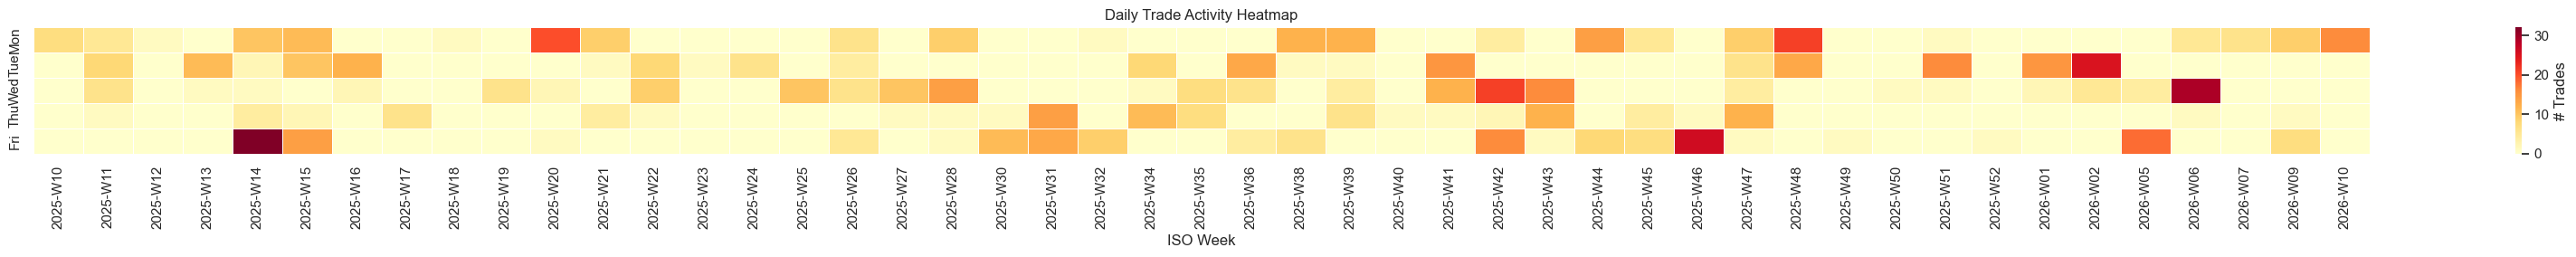

In [17]:
# Daily trade count heatmap (week × day-of-week)
daily_counts = df.groupby(df["trade_time"].dt.date).size().reset_index()
daily_counts.columns = ["date", "count"]
daily_counts["date"] = pd.to_datetime(daily_counts["date"])
daily_counts["week"]    = daily_counts["date"].dt.isocalendar().week.astype(int)
daily_counts["year"]    = daily_counts["date"].dt.isocalendar().year.astype(int)
daily_counts["weekday"] = daily_counts["date"].dt.weekday
daily_counts["yw"]      = daily_counts["year"].astype(str) + "-W" + daily_counts["week"].astype(str).str.zfill(2)

pivot = daily_counts.pivot_table(index="weekday", columns="yw", values="count", aggfunc="sum", fill_value=0)

fig, ax = plt.subplots(figsize=(max(12, len(pivot.columns) * 0.7), 3))
sns.heatmap(
    pivot,
    ax=ax,
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "# Trades"},
    yticklabels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"][:len(pivot)],
)
ax.set_title("Daily Trade Activity Heatmap")
ax.set_xlabel("ISO Week")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

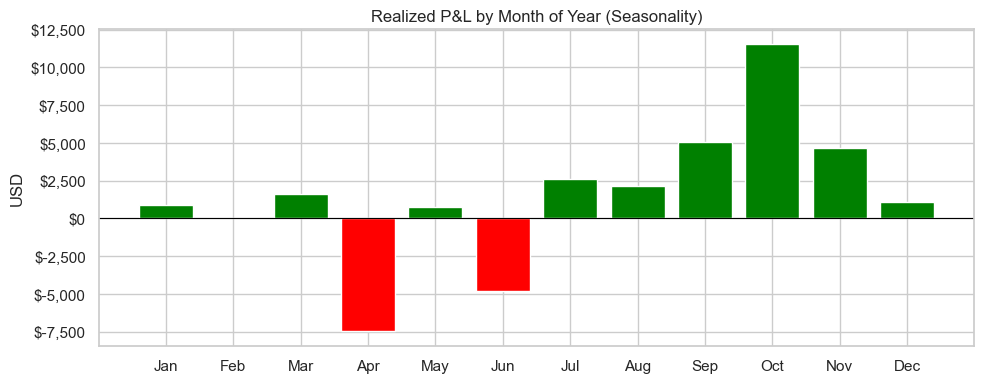

In [18]:
# P&L by calendar month
pnl_df2 = pnl_df.copy()
pnl_df2["month_num"] = pnl_df2["trade_time"].dt.month
month_pnl = pnl_df2.groupby("month_num")["realized_pnl"].sum()
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["green" if v >= 0 else "red" for v in month_pnl.values]
ax.bar([month_labels[m - 1] for m in month_pnl.index], month_pnl.values, color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Realized P&L by Month of Year (Seasonality)")
ax.set_ylabel("USD")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

## 7 — Commission Analysis

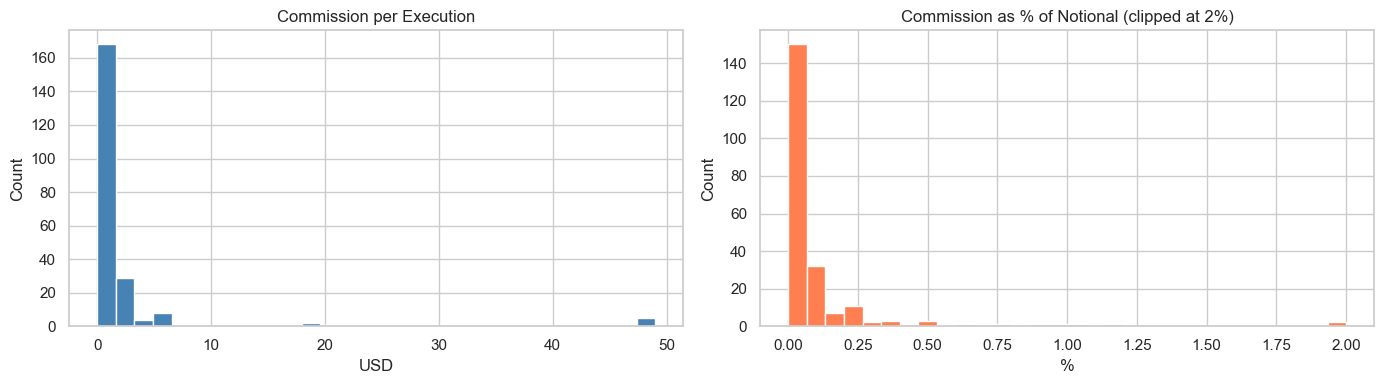

In [19]:
comm_df = df.dropna(subset=["commission"]).copy()
comm_df = comm_df[comm_df["commission"] > 0]  # exclude zero-commission rows
comm_df["comm_pct"] = comm_df["commission"] / comm_df["notional"] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution of commission per trade
axes[0].hist(comm_df["commission"], bins=30, edgecolor="white", color="steelblue")
axes[0].set_title("Commission per Execution")
axes[0].set_xlabel("USD")
axes[0].set_ylabel("Count")

# Commission % of notional
axes[1].hist(comm_df["comm_pct"].clip(0, 2), bins=30, edgecolor="white", color="coral")
axes[1].set_title("Commission as % of Notional (clipped at 2%)")
axes[1].set_xlabel("%")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [20]:
# Commission by symbol — total paid and average per trade
comm_by_sym = comm_df.groupby("symbol").agg(
    total_commission=("commission", "sum"),
    avg_commission=("commission", "mean"),
    avg_comm_pct=("comm_pct", "mean"),
    trade_count=("commission", "count"),
).sort_values("total_commission", ascending=False).head(15)

print("Top 15 symbols by total commission paid:")
display(comm_by_sym.style.format({
    "total_commission": "${:,.2f}",
    "avg_commission": "${:,.2f}",
    "avg_comm_pct": "{:.3f}%",
}))

Top 15 symbols by total commission paid:


,total_commission,avg_commission,avg_comm_pct,trade_count
symbol,,,,
NOVOBc,$245.00,$49.00,-0.265%,5
981,$38.46,$19.23,-0.003%,2
PLS,$18.00,$6.00,2.490%,3
1810,$18.00,$18.00,0.229%,1
SGLN,$18.00,$3.00,0.028%,6
LTR,$12.00,$6.00,2.395%,2
GOOGL,$10.10,$1.01,0.010%,10
OKLO,$10.03,$1.00,0.037%,10
LAR,$9.54,$1.91,-0.236%,5


## 8 — Success Metrics

In [21]:
pnl_series = pnl_df["realized_pnl"]

gross_profit = pnl_series[pnl_series > 0].sum()
gross_loss   = pnl_series[pnl_series < 0].sum()
profit_factor = abs(gross_profit / gross_loss) if gross_loss != 0 else float("inf")

avg_winner = pnl_series[pnl_series > 0].mean() if (pnl_series > 0).any() else 0
avg_loser  = pnl_series[pnl_series < 0].mean() if (pnl_series < 0).any() else 0
reward_risk = abs(avg_winner / avg_loser) if avg_loser != 0 else float("inf")

max_win  = pnl_series.max()
max_loss = pnl_series.min()

# Max drawdown on cumulative P&L
cum = pnl_df["cum_pnl"]
running_max = cum.cummax()
drawdown = cum - running_max
max_drawdown = drawdown.min()

# Approximate Sharpe (per-trade)
sharpe = (pnl_series.mean() / pnl_series.std() * np.sqrt(252)) if pnl_series.std() > 0 else float("nan")

print("══════════════════════════════════")
print(f"  Win Rate          : {win_rate:.1f}%")
print(f"  Profit Factor     : {profit_factor:.2f}")
print(f"  Avg Winner        : ${avg_winner:,.2f}")
print(f"  Avg Loser         : ${avg_loser:,.2f}")
print(f"  Reward/Risk Ratio : {reward_risk:.2f}")
print(f"  Largest Win       : ${max_win:,.2f}")
print(f"  Largest Loss      : ${max_loss:,.2f}")
print(f"  Max Drawdown      : ${max_drawdown:,.2f}")
print(f"  Approx Sharpe     : {sharpe:.2f}  (per-trade, annualised x√252)")
print("══════════════════════════════════")

══════════════════════════════════
  Win Rate          : 60.2%
  Profit Factor     : 1.82
  Avg Winner        : $677.58
  Avg Loser         : $-564.13
  Reward/Risk Ratio : 1.20
  Largest Win       : $5,169.14
  Largest Loss      : $-4,900.50
  Max Drawdown      : $-11,957.64
  Approx Sharpe     : 0.88  (per-trade, annualised x√252)
══════════════════════════════════


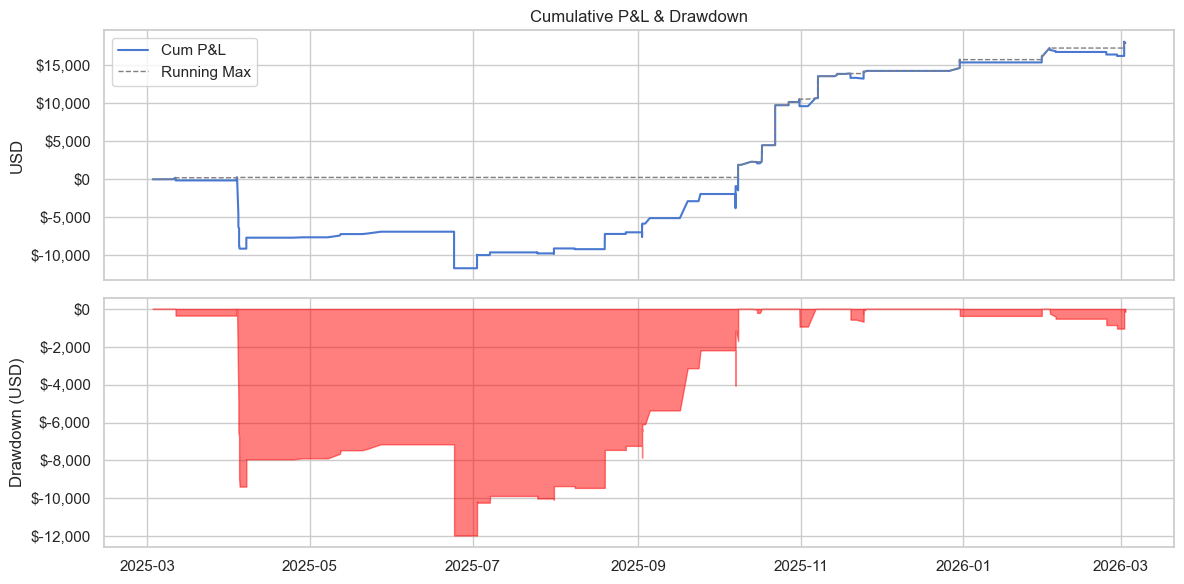

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(pnl_df["trade_time"], cum, linewidth=1.5, label="Cum P&L")
axes[0].plot(pnl_df["trade_time"], running_max, linestyle="--", linewidth=1, color="grey", label="Running Max")
axes[0].set_ylabel("USD")
axes[0].set_title("Cumulative P&L & Drawdown")
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

axes[1].fill_between(pnl_df["trade_time"], drawdown, 0, alpha=0.5, color="red")
axes[1].set_ylabel("Drawdown (USD)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.show()